<a href="https://colab.research.google.com/github/pikey-msc/AprendizMaquina/blob/main/2026-2/Conjuntos_de_entrenamiento_y_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# División de Conjuntos (Train, Val, Test)

Antes de tocar cualquier modelo, debemos decidir cómo vamos a evaluar si lo que estamos haciendo funciona o si solo estamos memorizando ruido. Como actuaría con formación en ciencias matemáticas, sabes que la validez de cualquier inferencia depende de la integridad de tu muestra.

## 1. La Santísima Trinidad del ML

Dividir tus datos no es opcional; es la única forma de evitar el autoengaño.

* **Train (Entrenamiento):** El "libro de texto". Aquí es donde el modelo ajusta sus pesos y aprende los patrones.
* **Validation (Validación):** El "examen simulacro". Lo usamos para ajustar hiperparámetros (como el $\lambda$ de Box-Cox o la profundidad de un árbol) sin contaminar el resultado final.
* **Test (Prueba):** El "examen real". Este conjunto está bajo llave. Solo se abre al final para reportar la capacidad real de generalización del modelo.



## 2. ¿Series Temporales o Datos Estáticos?

El método de separación depende totalmente de la naturaleza del dato. **Si el tiempo importa, el azar es tu enemigo.**

### A. Datos Estáticos (Independientes)
Si el orden de las filas no importa (ej. predecir el precio de una casa por sus metros cuadrados), usamos **Muestreo Aleatorio**.
* **Técnica:** `train_test_split`.
* **Riesgo:** Si no usas una semilla fija (`random_state`), tus resultados no serán replicables.

### B. Series Temporales (Dependientes)
Si los datos tienen una secuencia (ej. ventas diarias, precios de acciones o siniestralidad mensual), **NUNCA** uses muestreo aleatorio.
* **Regla de Oro:** El futuro no puede entrenar al pasado.
* **Técnica:** Partición cronológica (Time-Based Split). Entrenas con los primeros $n$ meses y pruebas con los últimos $m$ meses.


## 3. ¿Cuándo usar 2 o 3 conjuntos? (El Tablero de Decisión)

| Escenario | Conjuntos Necesarios | ¿Por qué? |
| :--- | :---: | :--- |
| **Modelos de "Caja Negra" (XGBoost, Redes Neuronal)** | **3** (Train/Val/Test) | Necesitas el Val para decidir cuándo dejar de entrenar y evitar el sobreajuste. |
| **Modelos Lineales Simples** | **2** (Train/Test) | Si no vas a tunear hiperparámetros, con un Test Set robusto basta. |
| **Datasets Pequeños** | **Cross-Validation** | Cuando no hay suficientes datos para un Test digno, usamos K-Fold para rotar los conjuntos. |


## Mañas:

1.  **Estratificación:** Si tu target está desbalanceado (ej. solo el 2% de los clientes son fraudulentos), usa `stratify=target`. Esto asegura que esa proporción se mantenga en todos tus conjuntos.
2.  **El Muro de Berlín:** Una vez que separas el **Test Set**, no lo vuelvas a mirar. No le limpies nulos, no le quites outliers basándote en su propia media. **Todo lo que le hagas al Test debe venir de la "memoria" del Train.**
3.  **Shuffle:** Haz shuffle en datos estáticos para eliminar sesgos de recolección, pero apágalo por completo si trabajas con series de tiempo.

In [1]:
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

# Generador de datos para el laboratorio
def generar_dataset_pro(n=1000):
    np.random.seed(42)

    # 1. Componente Temporal
    fechas = pd.date_range(start='2020-01-01', periods=n, freq='D')

    # 2. Variable Continua (Ventas con tendencia)
    ventas = np.cumsum(np.random.normal(0.1, 1, n)) + 100

    # 3. Variable Categórica Desbalanceada (Riesgo Siniestral)
    # 95% Buenos (0), 5% Malos (1)
    riesgo = np.random.choice([0, 1], size=n, p=[0.95, 0.05])

    # 4. Otras variables para bulto
    edad = np.random.randint(18, 80, n)
    score = np.random.normal(600, 100, n)

    df = pd.DataFrame({
        'fecha': fechas,
        'ventas': ventas,
        'edad': edad,
        'score_crediticio': score,
        'riesgo': riesgo
    })

    return df

# Creamos el dataframe maestro
df = generar_dataset_pro()

print("✅ Dataset generado exitosamente.")
print(df.head())
print(f"\nDistribución del Riesgo:\n{df['riesgo'].value_counts(normalize=True)}")

# 1. Caso Estático: Muestreo Aleatorio Estratificado
# Supongamos que 'df' es tu dataset y 'riesgo' es tu target
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('riesgo', axis=1),
    df['riesgo'],
    test_size=0.2,
    random_state=42,
    stratify=df['riesgo'] # <--- Clave para no sesgar
)

# 2. Caso Temporal: Corte Cronológico
# Ordenamos por fecha primero
df = df.sort_values('fecha')
split_idx = int(len(df) * 0.8)

train_ts = df.iloc[:split_idx]
test_ts = df.iloc[split_idx:]

print(f"Train temporal termina en: {train_ts['fecha'].max()}")
print(f"Test temporal inicia en: {test_ts['fecha'].min()}")

✅ Dataset generado exitosamente.
       fecha      ventas  edad  score_crediticio  riesgo
0 2020-01-01  100.596714    79        575.908875       0
1 2020-01-02  100.558450    25        445.434986       0
2 2020-01-03  101.306138    60        656.231662       0
3 2020-01-04  102.929168    37        641.726345       0
4 2020-01-05  102.795015    77        713.770620       0

Distribución del Riesgo:
riesgo
0    0.945
1    0.055
Name: proportion, dtype: float64
Train temporal termina en: 2022-03-10 00:00:00
Test temporal inicia en: 2022-03-11 00:00:00


## Balanceo de Clases: ¿Cuándo y cómo intervenir?

Si después de hacer tu división estratificada notas que tu modelo no es capaz de aprender la clase minoritaria (ej. el riesgo de siniestro), es momento de aplicar técnicas de balanceo.

### 1. ¿Cuándo se utiliza?
No siempre es necesario balancear. Se utiliza cuando:
* El **desbalance es extremo** (ej. 1% de casos positivos).
* El modelo tiene un **sesgo masivo** hacia la clase mayoritaria (Accuracy alto, Recall de cero).
* Estás usando algoritmos sensibles al balance (como SVM o Redes Neuronales básicas).

### 2. La Regla de Oro: Solo en el Entrenamiento (Train)
**NUNCA** balancees el conjunto de Prueba (Test). El Test debe representar la realidad "sucia" y desbalanceada. Si balanceas el Test, estarías evaluando tu modelo en un mundo de fantasía.



### 3. Técnicas y qué hacer con "lo que sobra"

Cuando haces **Under-sampling** (reducir la clase mayoritaria), muchos registros quedan fuera del entrenamiento. **No los tires a la basura:**

* **Under-sampling:** Reducimos los "Buenos" para igualar a los "Malos".
    * *¿Qué hacer con el resto?:* Úsalos como un **Hold-out Set de Validación Externa**. Si tu modelo entrenado con datos balanceados funciona bien en este set desbalanceado, vas por buen camino.
* **Over-sampling (SMOTE):** Creamos ejemplos sintéticos de los "Malos".
    * *Riesgo:* Puedes generar **Overfitting** si los datos sintéticos son demasiado parecidos a los reales.
* **Calibración de Probabilidades:** Al balancear artificialmente, el modelo creerá que el riesgo es del 50%. Debes usar los datos que quedaron fuera para recalibrar las probabilidades y que vuelvan a reflejar el 5% real.

## Estrategias de Muestreo: Under-sampling y Over-sampling

Cuando trabajamos con datos desbalanceados (ej. siniestros que solo ocurren en el 5% de los casos), el modelo tiende a ignorar la clase minoritaria. Para corregir esto, aplicamos técnicas de balanceo **exclusivamente en el conjunto de entrenamiento**.


## Under-sampling (El "Club Selecto")
**Escenario:** Tienes millones de datos (Big Data) y el riesgo es muy raro.
* **¿Qué hace?:** Elimina registros de la clase mayoritaria ("Buenos") para igualar el número de la minoritaria ("Malos").
* **¿Qué hacer con los datos que "sobran"?:** * **Validación de Robustez:** Úsalos para pasar el modelo final. Si el modelo es bueno, debería clasificar correctamente a esos "Buenos" que nunca vio.
    * **Calibración:** Úsalos para ajustar las probabilidades. Un modelo entrenado 50/50 será muy alarmista; estos datos excedentes ayudan a recalibrar el modelo a la realidad del 5%.



## Over-sampling (SMOTE - "Gemelos Sintéticos")
**Escenario:** Tienes pocos datos y no puedes permitirte borrar registros.
* **¿Qué hace?:** Crea datos nuevos basados en los "vecinos" (K-NN) de la clase minoritaria. No es solo duplicar filas; es crear puntos intermedios matemáticamente plausibles.
* **Riesgo:** Si generas demasiados "fantasmas", el modelo se memoriza los datos sintéticos (**Overfitting**) y fallará con datos reales.



## Mañas
1.  **Recall > Precision:** En seguros y riesgos financieros, nos sale más caro ignorar un incendio (Bajo Recall) que investigar una falsa alarma (Baja Precision). El balanceo busca maximizar el **Recall**.
2.  **El Muro de Berlín:** Si aplicas SMOTE a todo el dataset antes de separarlos, el modelo "verá" datos sintéticos en el Test que fueron creados con información del Train. Eso es **Data Leakage** y es causa de reprobación inmediata.
3.  **No balancees el Test:** Evaluar un modelo en un conjunto balanceado artificialmente es mentirse a uno mismo. El mundo real está desbalanceado.

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1. GENERACIÓN DEL DATASET (95/5)
def generar_dataset_siniestros(n=2000):
    np.random.seed(42)
    target = np.random.choice([0, 1], size=n, p=[0.95, 0.05])
    edad = np.random.randint(18, 80, n)
    score = np.random.normal(600, 100, n)
    score[target == 1] -= 150
    return pd.DataFrame({'edad': edad, 'score': score, 'target': target})

df = generar_dataset_siniestros()
X = df.drop('target', axis=1)
y = df['target']

# 2. SPLIT ORIGINAL EN 3: Train (60%), Val (20%), Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# --- OPCIÓN A: BALANCEO POR UNDER-SAMPLING (1:1) ---
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# 2.1 EXTRACCIÓN DEL PURGATORIO (El complemento de la Opción A)
# Son los registros que estaban en el Train original pero NO en el Under-sampled
purgatorio_indices = X_train.index.difference(X_train_under.index)
X_purgatorio = X_train.loc[purgatorio_indices]
y_purgatorio = y_train.loc[purgatorio_indices]

# --- OPCIÓN B: BALANCEO POR OVER-SAMPLING (SMOTE 1:1) ---
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# 3. REPORTE COMPARATIVO DE CONJUNTOS
def get_stats(y_set):
    counts = np.bincount(y_set)
    # Manejo de casos donde solo hay una clase (como en el Purgatorio)
    m_count = counts[1] if len(counts) > 1 else 0
    return f"B:{counts[0]:4} | M:{m_count:3} ({ (m_count/len(y_set))*100:.1f}%)"

print("="*75)
print(f"{'CONJUNTO':25} | {'DISTRIBUCIÓN (Buenos vs Malos)':35} | {'USO TÁCTICO'}")
print("="*75)
print(f"{'Validación (Original)':25} | {get_stats(y_val)} | Ajuste Hiperparámetros")
print(f"{'Test (Original)':25} | {get_stats(y_test)} | Reporte Final")
print("-"*75)
print(f"{'OPCIÓN A: Train Under':25} | {get_stats(y_train_under)} | Entrenamiento Rápido")
print(f"{'PURGATORIO (Sobrante A)':25} | {get_stats(y_purgatorio)} | Calibración/Estrés")
print("-"*75)
print(f"{'OPCIÓN B: Train Over':25} | {get_stats(y_train_over)} | Entrenamiento SMOTE")
print("="*75)

# Verificación de "Don Chingón"
total = len(y_train_under) + len(y_purgatorio) + len(y_val) + len(y_test)
print(f"\nSuma Total de registros: {total} (Deberían ser 2000)")

CONJUNTO                  | DISTRIBUCIÓN (Buenos vs Malos)      | USO TÁCTICO
Validación (Original)     | B: 379 | M: 21 (5.2%) | Ajuste Hiperparámetros
Test (Original)           | B: 379 | M: 21 (5.2%) | Reporte Final
---------------------------------------------------------------------------
OPCIÓN A: Train Under     | B:  63 | M: 63 (50.0%) | Entrenamiento Rápido
PURGATORIO (Sobrante A)   | B:1074 | M:  0 (0.0%) | Calibración/Estrés
---------------------------------------------------------------------------
OPCIÓN B: Train Over      | B:1137 | M:1137 (50.0%) | Entrenamiento SMOTE

Suma Total de registros: 2000 (Deberían ser 2000)


/tmp/ipython-input-3194435146.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train_under[y_train_under == 0]['score'], label='Train Under (Los elegidos)', shade=True, color='blue', lw=2)
/tmp/ipython-input-3194435146.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_purgatorio['score'], label='Purgatorio (El complemento)', shade=True, color='gray', linestyle='--', lw=2)


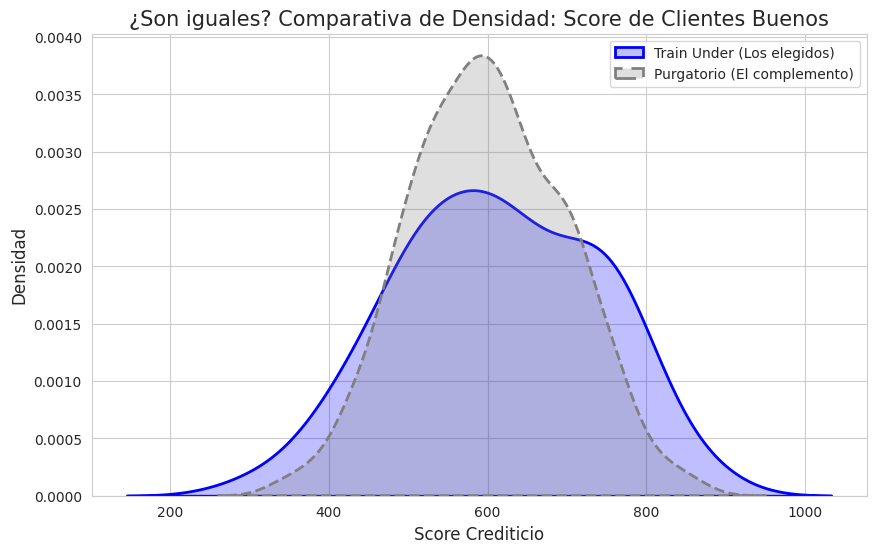

Media Score (Train Under): 612.53
Media Score (Purgatorio):  600.60


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo "Don Chingón"
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Graficamos la densidad del 'score' para ambos conjuntos
sns.kdeplot(X_train_under[y_train_under == 0]['score'], label='Train Under (Los elegidos)', shade=True, color='blue', lw=2)
sns.kdeplot(X_purgatorio['score'], label='Purgatorio (El complemento)', shade=True, color='gray', linestyle='--', lw=2)

plt.title('¿Son iguales? Comparativa de Densidad: Score de Clientes Buenos', fontsize=15)
plt.xlabel('Score Crediticio', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.show()

print(f"Media Score (Train Under): {X_train_under[y_train_under == 0]['score'].mean():.2f}")
print(f"Media Score (Purgatorio):  {X_purgatorio['score'].mean():.2f}")

### ¿Qué hacemos con los datos que "sobran"?

En el **Under-sampling**, el "Purgatorio" es el conjunto de registros de la clase mayoritaria que decidimos no usar para entrenar el modelo. Para un actuario, estos datos no son basura; son la herramienta de auditoría más potente que tenemos.


## 1. Auditoría de "Paranoia" (Falsos Positivos)
Como sabemos que el 100% de los registros en el Purgatorio son **Buenos**, cualquier predicción de "Riesgo" que el modelo haga sobre ellos es un error.
* **Uso:** Calcula la tasa de error específica en clientes sanos. Si el modelo es muy "paranoico" debido al balanceo 1:1, aquí lo vas a detectar antes de salir a producción.

## 2. Calibración de Probabilidades
Cuando entrenas un modelo 50/50, las probabilidades que escupe el modelo están "infladas". El modelo cree que el mundo es mucho más peligroso de lo que realmente es.
* **Uso:** Utilizamos el Purgatorio junto con la Validación para aplicar técnicas como **Platt Scaling** o **Isotonic Regression**. Esto ajusta la salida del modelo para que la probabilidad predicha refleje la frecuencia real del 5% de siniestralidad.

$$P_{real} \approx f(P_{modelo\_balanceado})$$

## 3. Análisis de Sesgo (Bias Detection)
¿El modelo está rechazando desproporcionadamente a gente joven en el Purgatorio? ¿O a gente con cierto score?
* **Uso:** Al tener un volumen masivo de datos que el modelo nunca vio, podemos hacer **Stress Testing** por segmentos para asegurar que el modelo sea justo y no esté penalizando de más a un grupo específico de clientes buenos.


> **Mantra Actuarial:** "El entrenamiento (Train) es para la potencia; el Purgatorio es para la precisión y la decencia del negocio".

# Validación Cruzada (Cross-Validation): La Auditoría de la Generalización

En Machine Learning y Ciencia de Datos, el objetivo central no es minimizar el error de entrenamiento ($Err_{train}$), sino estimar el **Riesgo de Generalización** ($\mathcal{R}_{gen}$). La Validación Cruzada es un estimador estadístico de este riesgo que reduce la varianza de la evaluación al promediar los resultados sobre múltiples particiones del espacio de datos.



## 1. El Fundamento Matemático

Si tenemos un dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$, el error de validación cruzada para $K$ folds se define formalmente como:

$$CV_{(K)} = \frac{1}{K} \sum_{k=1}^{K} L(\hat{f}^{-k}, \mathcal{D}_k)$$

Donde:
* $\mathcal{D}_k$ es el $k$-ésimo subconjunto (fold) que actúa como prueba en esa iteración.
* $\hat{f}^{-k}$ es el modelo ajustado **excluyendo** el subconjunto $\mathcal{D}_k$.
* $L$ es la función de pérdida (ej. Log-Loss para clasificación o MSE para regresión).

Para un rigor actuarial, calculamos el **Error Estándar** de la métrica para medir su estabilidad estadística:
$$SE(CV_K) = \sqrt{\frac{1}{K-1} \sum_{k=1}^K (Err_k - \overline{Err})^2}$$
Un $SE$ elevado indica inestabilidad: el desempeño del modelo depende excesivamente de la muestra específica de entrenamiento.


## 2. Taxonomía de Métodos (Nivel Pro)

### A. Stratified K-Fold (El estándar de Riesgos)
En eventos de baja frecuencia (ej. siniestros del 5%), un K-Fold aleatorio puede dejar folds sin un solo evento positivo.
* **Técnica:** Preserva la probabilidad marginal del target $P(Y)$ en cada fold, garantizando que:
$$\frac{n_{1,k}}{n_k} \approx \frac{N_1}{N}$$
para todo $k \in \{1, \dots, K\}$.
* **Uso:** **Mandatorio** en clasificación desbalanceada para evitar sesgos en la estimación de la precisión.



### B. Leave-One-Out (LOOCV)
Es el límite donde $K = n$.
* **Propiedad:** Es un estimador casi insesgado de $\mathcal{R}_{gen}$ al utilizar $n-1$ datos para entrenar.
* **Costo:** Alta varianza debido a la correlación entre modelos y costo computacional inviable para $n$ grandes.

### C. Time Series Split (Walk-Forward Validation)
En series temporales, romper el orden es violar la causalidad. No podemos predecir el pasado usando datos del futuro.
* **Mecánica:** Se define un horizonte de entrenamiento que se expande o desliza cronológicamente:
$$\mathcal{D}_{train, i} = \{t_1, \dots, t_i\} \implies \mathcal{D}_{val, i} = \{t_{i+1}, \dots, t_{i+h}\}$$




## 3. El Dilema Sesgo-Varianza en la Elección de $K$

Al seleccionar el número de folds $K$, el matemático debe considerar el compromiso:

1.  **$K$ Pequeño (ej. 2 o 5):**
    * **Sesgo Alto:** Entrenas con pocos datos, lo que suele sobreestimar el error real.
    * **Varianza Baja:** Los modelos son más diversos entre sí, promediando mejor el ruido.
2.  **$K$ Grande (ej. 10 o LOOCV):**
    * **Sesgo Bajo:** La estimación es muy cercana al rendimiento real esperado.
    * **Varianza Alta:** Los modelos están altamente correlacionados, volviendo la estimación inestable ante cambios mínimos en los datos.




## Mañas

* **Primero el Split, luego la CV:** Siempre separa tu **Test Set** (el 20% sagrado) antes de iniciar la validación cruzada. La CV se realiza exclusivamente sobre el bloque de desarrollo.
* **Pipeline es Ley:** Si aplicas escalado o balanceo (SMOTE), ¡hazlo **dentro** de cada fold! Procesar todo el dataset antes de la CV provoca **Data Leakage** al filtrar información de validación al entrenamiento.
* **Estabilidad sobre Promedio:** Un F1-Score promedio de 0.85 con un $SE$ de 0.15 es una moneda al aire. Prefiere un 0.82 con un $SE$ de 0.01; eso es robustez matemática real.

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit

# Dataset miniatura para visualizar
X_mini = np.arange(10).reshape((5, 2))
y_mini = np.array([0, 0, 1, 0, 1])

# --- Visualizando K-Fold ---
kf = KFold(n_splits=3)
print("--- K-FOLD INDICES ---")
for train_idx, val_idx in kf.split(X_mini):
    print(f"TRAIN: {train_idx} | VAL: {val_idx}")

# --- Visualizando TimeSeriesSplit ---
tss = TimeSeriesSplit(n_splits=3)
print("\n--- TIME SERIES INDICES ---")
for train_idx, val_idx in tss.split(X_mini):
    print(f"TRAIN: {train_idx} | VAL: {val_idx}")

## Algoritmos de Partición: La Lógica "A Patita"

Para dominar la validación cruzada, hay que entender cómo se manipulan los punteros e índices sobre un conjunto $\mathcal{I} = \{0, 1, \dots, n-1\}$. Aquí está la carpintería detrás de cada método:


### 1. K-Fold (El Reparto Equitativo)
**Lógica:** Dividir el espacio muestral en $K$ bloques contiguos tras una permutación aleatoria.

1. **Permutación:** Se genera una secuencia aleatoria de índices $\pi(\mathcal{I})$.
2. **Tamaño del bloque:** Se calcula $m = \lfloor n/K \rfloor$.
3. **Iteración:** Para cada fold $k \in \{1, \dots, K\}$:
   * **Índices de Validación ($V_k$):** El bloque actual de tamaño $m$.
   * **Índices de Entrenamiento ($T_k$):** El resto de los índices ($\mathcal{I} \setminus V_k$).



### 2. Stratified K-Fold (Estratificación Actuarial)
**Lógica:** Garantizar que la proporción de la clase minoritaria (siniestros) se mantenga constante en cada fold.

1. **Agrupación:** Separar índices por etiqueta: $\mathcal{I}_0$ (Buenos) e $\mathcal{I}_1$ (Siniestros).
2. **Sub-partición:** Aplicar la lógica de K-Fold de forma independiente a $\mathcal{I}_0$ y a $\mathcal{I}_1$.
3. **Fusión:** Para cada fold $k$, unir los sub-bloques: $V_k = V_{0,k} \cup V_{1,k}$ y $T_k = T_{0,k} \cup T_{1,k}$.
4. **Resultado:** Se mantiene la proporción marginal $P(Y)$ en cada iteración.




### 3. Time Series Split (Walk-Forward)
**Lógica:** Respetar la causalidad temporal (no puedes usar el futuro para predecir el pasado).

1. **Ordenamiento:** Los índices deben seguir el orden cronológico: $t_0 < t_1 < \dots < t_{n-1}$.
2. **Ventana Expandida:** El entrenamiento crece mientras la validación se desplaza:
   * $T_k = \{0, \dots, n_{train} + k \cdot h - 1\}$
   * $V_k = \{n_{train} + k \cdot h, \dots, n_{train} + (k+1) \cdot h - 1\}$



# 4. Leave-One-Out Cross-Validation (LOOCV): El Límite de la Validación

El **LOOCV** es un caso particular de K-Fold donde $K = n$ (el número total de registros). Cada observación se convierte, por turno, en el conjunto de validación, mientras que las $n-1$ restantes forman el entrenamiento.


## 1. Lógica Algorítmica
1. **Iteración:** Para cada índice $i$ desde $0$ hasta $n-1$:
   * **Validación ($V_i$):** El registro en la posición $i$.
   * **Entrenamiento ($T_i$):** Todos los registros excepto el $i$.
2. **Evaluación:** Se entrena el modelo $n$ veces y se promedia el error.

##  Ventajas y Riesgos Actuariales
* **Insesgado:** Al usar $n-1$ datos para entrenar, la estimación del error es casi idéntica a la del modelo final.
* **Costo Computacional:** Si tienes un dataset de 10,000 pólizas, tienes que entrenar el modelo 10,000 veces. **Es prohibitivo para modelos complejos**.
* **Varianza:** Al estar los conjuntos de entrenamiento tan correlacionados (solo difieren en un dato), el promedio de los errores puede tener una varianza alta.



In [9]:
##  Implementación Manual del K-Fold (Sin Sklearn)

#Para entender qué hace Python por debajo, aquí está el algoritmo usando solo **Numpy**:

import numpy as np

def kfold_a_patita(n_samples, n_splits=5, shuffle=True):
    # 1. Crear índices y barajarlos
    indices = np.arange(n_samples)
    if shuffle:
        np.random.shuffle(indices)

    # 2. Definir tamaños de bloques (manejando el residuo)
    fold_sizes = np.full(n_splits, n_samples // n_splits)
    fold_sizes[:n_samples % n_splits] += 1

    current = 0
    folds = []

    for size in fold_sizes:
        start, stop = current, current + size

        # Segmentar validación y entrenamiento
        val_idx = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]])

        folds.append((train_idx, val_idx))
        current = stop

    return folds

# --- PRUEBA DEL ALGORITMO ---
indices_generados = kfold_a_patita(n_samples=10, n_splits=3)

for i, (train, val) in enumerate(indices_generados):
    print(f"Fold {i+1} | Train Indices: {train} | Val Indices: {val}")

Fold 1 | Train Indices: [6 5 4 0 2 9] | Val Indices: [3 7 8 1]
Fold 2 | Train Indices: [3 7 8 1 0 2 9] | Val Indices: [6 5 4]
Fold 3 | Train Indices: [3 7 8 1 6 5 4] | Val Indices: [0 2 9]


In [10]:
## 1. Stratified K-Fold Manual
#**Objetivo:** Mantener la proporción de clases en cada fold.
#**Lógica:** Separamos los índices por etiqueta, aplicamos un K-Fold independiente a cada grupo y luego los fusionamos.

import numpy as np

def stratified_kfold_manual(y, n_splits=5, shuffle=True):
    # 1. Identificar índices por clase
    indices_clase_0 = np.where(y == 0)[0]
    indices_clase_1 = np.where(y == 1)[0]

    if shuffle:
        np.random.shuffle(indices_clase_0)
        np.random.shuffle(indices_clase_1)

    # 2. Función auxiliar para repartir en bloques (folds)
    def split_indices(indices, k):
        n = len(indices)
        fold_sizes = np.full(k, n // k)
        fold_sizes[:n % k] += 1
        current = 0
        blocks = []
        for size in fold_sizes:
            blocks.append(indices[current:current + size])
            current += size
        return blocks

    # 3. Crear los pedacitos (folds) para cada clase
    folds_0 = split_indices(indices_clase_0, n_splits)
    folds_1 = split_indices(indices_clase_1, n_splits)

    # 4. Fusionar y generar pares (train, val)
    final_folds = []
    for i in range(n_splits):
        # El bloque de validación es la unión de los pedacitos i de cada clase
        val_idx = np.concatenate([folds_0[i], folds_1[i]])

        # El bloque de entrenamiento es el resto
        train_idx_0 = np.concatenate([folds_0[j] for j in range(n_splits) if j != i])
        train_idx_1 = np.concatenate([folds_1[j] for j in range(n_splits) if j != i])
        train_idx = np.concatenate([train_idx_0, train_idx_1])

        final_folds.append((train_idx, val_idx))

    return final_folds

# --- PRUEBA ESTRATIFICADA ---
y_ejemplo = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1]) # 50/50
folds_estrat = stratified_kfold_manual(y_ejemplo, n_splits=2)

for i, (train, val) in enumerate(folds_estrat):
    print(f"Fold {i+1} | Val Indices: {val} | Prop. Clase 1: {y_ejemplo[val].mean():.1f}")

Fold 1 | Val Indices: [0 4 2 6 5 7] | Prop. Clase 1: 0.5
Fold 2 | Val Indices: [1 3 8 9] | Prop. Clase 1: 0.5


In [11]:
import numpy as np

def timeseries_split_manual(n_samples, n_splits=5):
    # En series de tiempo, la longitud de la validación (test) es fija
    test_size = n_samples // (n_splits + 1)

    folds = []
    for i in range(n_splits):
        # El entrenamiento crece en cada iteración
        train_end = (i + 1) * test_size
        val_end = train_end + test_size

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)

        folds.append((train_idx, val_idx))

    return folds

# --- PRUEBA DE TIEMPO ---
n_total = 12 # 12 meses de datos
folds_tiempo = timeseries_split_manual(n_total, n_splits=3)

for i, (train, val) in enumerate(folds_tiempo):
    print(f"Fold {i+1} | Train: {train} | Val (Futuro): {val}")

Fold 1 | Train: [0 1 2] | Val (Futuro): [3 4 5]
Fold 2 | Train: [0 1 2 3 4 5] | Val (Futuro): [6 7 8]
Fold 3 | Train: [0 1 2 3 4 5 6 7 8] | Val (Futuro): [ 9 10 11]


In [12]:
import numpy as np

def loocv_manual(n_samples):
    indices = np.arange(n_samples)
    folds = []

    for i in range(n_samples):
        # El registro i es validación
        val_idx = np.array([indices[i]])

        # Todo lo demás es entrenamiento
        train_idx = np.delete(indices, i)

        folds.append((train_idx, val_idx))

    return folds

# --- PRUEBA DEL ALGORITMO ---
n_registros = 5
indices_loocv = loocv_manual(n_registros)

print(f"--- LOOCV PARA {n_registros} REGISTROS ---")
for i, (train, val) in enumerate(indices_loocv):
    print(f"Iteración {i+1} | Train: {train} | Val: {val}")

--- LOOCV PARA 5 REGISTROS ---
Iteración 1 | Train: [1 2 3 4] | Val: [0]
Iteración 2 | Train: [0 2 3 4] | Val: [1]
Iteración 3 | Train: [0 1 3 4] | Val: [2]
Iteración 4 | Train: [0 1 2 4] | Val: [3]
Iteración 5 | Train: [0 1 2 3] | Val: [4]


Mientras que en el K-Fold normal barajeamos todo como mazo de cartas, en el Stratified cuidamos que el 'casino' no nos robe las cartas raras (siniestros) y en el Time Series prohibimos mirar la siguiente carta del mazo. Es puro control de índices.